In [ ]:
# =============================================================================
# FRAUD DETECTION PIPELINE  —  FULLY LEAK-FREE  (v7)
# =============================================================================
#
# Changes vs v6
# ────────────────────────────────────────────────────────────────────────────
# • GroupKFold in Optuna CV — same card never appears in both fold-train
#   and fold-val, preventing card-level leakage inside hyperparameter search
# • try/except guard on all Optuna objectives — GPU OOM or num_leaves >
#   2^max_depth crashes return 0.0 instead of aborting the study
# • Sequence features: shift(1) + fillna(global_mean) — removes temporal
#   peeking and neutral-baseline for first card transaction
# • uid_txn_1h removed from model features (kept only for txn_ratio)
# • New features: amt_change, log_time_gap, txn_ratio, clipped extremes
# • Ensemble score + best-F1 threshold tuning in evaluation
# • SHAP_N_SAMPLE 5k → 8k,  OPTUNA_TRIALS 80 → 50 (same quality, faster)
# =============================================================================

import json, warnings, gc, time
import numpy  as np
import pandas as pd
import lightgbm as lgb
import xgboost  as xgb
import catboost as cb
import optuna, shap, joblib
import matplotlib; matplotlib.use("Agg")
import matplotlib.pyplot as plt

from datasets import load_dataset
from sklearn.model_selection import (
    GroupShuffleSplit, GroupKFold, train_test_split
)
from sklearn.preprocessing   import LabelEncoder
from sklearn.calibration      import CalibratedClassifierCV
from sklearn.metrics         import (
    average_precision_score, roc_auc_score,
    precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    precision_recall_curve, roc_curve,
)

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

XGB_VER = tuple(int(x) for x in xgb.__version__.split(".")[:2])
XGB_GPU = {"device":"cuda","tree_method":"hist"} if XGB_VER >= (2,0) \
          else {"tree_method":"gpu_hist"}

# ── Config ───────────────────────────────────────────────────────────────
TARGET           = "is_fraud"
RANDOM_STATE     = 42
TEST_SIZE        = 0.20
SHAP_N_SAMPLE    = 8_000
OPTUNA_TRIALS    = 50
OPTUNA_CV        = 3
OPTUNA_MAX_ROWS  = 200_000
ES_ROUNDS        = 50
ES_FRAC          = 0.10
CATEGORICAL_COLS = ["merchant_clean", "category", "gender", "state", "job"]
UNSEEN           = "<unseen>"

COLS_TO_DROP = [
    "trans_date_trans_time", "dob", "cc_num", "zip",
    "lat", "long", "merch_lat", "merch_long",
    "unix_time", "city", "merchant",
    "first", "last", "street", "trans_num", "card_uid",
]


# =============================================================================
# STAGE 0 — LOAD & CLEAN
# =============================================================================
print("\n" + "=" * 70)
print("STAGE 0 — LOAD & CLEAN")
print("=" * 70)

dataset = load_dataset("dazzle-nu/CIS435-CreditCardFraudDetection",
                       split="train", num_proc=2)
df = dataset.to_pandas(); del dataset; gc.collect()

# Drop junk columns
drop = (df.columns[df.isnull().all()].tolist()
        + [c for c in df.columns if "Unnamed" in str(c)] + ["6006"])
df.drop(columns=drop, inplace=True, errors="ignore")
df.drop(columns=["first","last","street","trans_num"], inplace=True, errors="ignore")

# Fix dtypes
df["cc_num"] = df["cc_num"].astype(np.int64).astype(str)
df["zip"]    = df["zip"].astype(str).str.strip()
for c in df.select_dtypes("float64").columns: df[c] = df[c].astype(np.float32)
for c in df.select_dtypes("int64").columns:
    if c != TARGET: df[c] = df[c].astype(np.int32)
df.drop_duplicates(inplace=True)
df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"])
df = df.sort_values("trans_date_trans_time").reset_index(drop=True)

# ── FIX 1: Strip the "fraud_" prefix from merchant names ─────────────────
# This prefix directly encodes the target label — removing it is mandatory.
# We keep a cleaned version "merchant_clean" for encoding.
df["merchant_clean"] = df["merchant"].str.replace(r"^fraud_", "", regex=True).str.strip()
n_fraud_prefix = df["merchant"].str.startswith("fraud_").sum()
print(f"Stripped 'fraud_' prefix from {n_fraud_prefix:,} merchant entries.")

# ── FIX 2: Build composite UID (grouping key only — never a model feature) ─
# cc_num  : card identity
# dob     : cardholder identity (prevents cc_num collisions across issuers)
# zip     : registered address (anchors spatial baseline)
df["card_uid"] = df["cc_num"] + "_" + df["dob"].astype(str) + "_" + df["zip"]

print(f"Unique cc_num   : {df['cc_num'].nunique():,}")
print(f"Unique card_uid : {df['card_uid'].nunique():,}")
print(f"Cleaned shape   : {df.shape}")
print(f"Fraud rate      : {df[TARGET].mean():.4%}")


# =============================================================================
# STAGE 1 — GROUP SPLIT  (by card_uid — no cardholder in both splits)
# =============================================================================
print("\n" + "=" * 70)
print("STAGE 1 — GROUP SPLIT (by card_uid)")
print("=" * 70)

gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(df, df[TARGET], groups=df["card_uid"]))

train_df = df.iloc[train_idx].copy().reset_index(drop=True)
test_df  = df.iloc[test_idx].copy().reset_index(drop=True)
del df; gc.collect()

overlap = set(train_df["card_uid"]) & set(test_df["card_uid"])
assert len(overlap) == 0, f"Card UID leakage: {len(overlap)} UIDs in both splits"

print(f"Train : {len(train_df):,} rows | fraud {train_df[TARGET].mean():.4%}")
print(f"Test  : {len(test_df):,}  rows | fraud {test_df[TARGET].mean():.4%}")
print("card_uid overlap : 0 ✓")
# ── test_df untouched until Stage 8 ──────────────────────────────────────


# =============================================================================
# STAGE 2 — FEATURE ENGINEERING  (all fitters trained on train_df only)
# =============================================================================
print("\n" + "=" * 70)
print("STAGE 2 — FEATURE ENGINEERING")
print("=" * 70)

# ── A. Deterministic transforms (no fitting step) ────────────────────────
def add_deterministic(df):
    dt  = pd.to_datetime(df["trans_date_trans_time"])
    dob = pd.to_datetime(df["dob"])
    df["hour"]        = dt.dt.hour.astype(np.int8)
    df["day_of_week"] = dt.dt.dayofweek.astype(np.int8)
    df["month"]       = dt.dt.month.astype(np.int8)
    df["is_weekend"]  = (dt.dt.dayofweek >= 5).astype(np.int8)
    df["age"]         = ((dt - dob).dt.days / 365.25).astype(np.int16)
    R     = np.float32(6371.0)
    rlat1 = np.radians(df["lat"].values.astype(np.float32))
    rlon1 = np.radians(df["long"].values.astype(np.float32))
    rlat2 = np.radians(df["merch_lat"].values.astype(np.float32))
    rlon2 = np.radians(df["merch_long"].values.astype(np.float32))
    dlat, dlon = rlat2 - rlat1, rlon2 - rlon1
    a = np.sin(dlat/2)**2 + np.cos(rlat1)*np.cos(rlat2)*np.sin(dlon/2)**2
    df["distance_km"]  = (2*R*np.arcsin(np.sqrt(a))).astype(np.float32)
    df["log_amt"]      = np.log1p(df["amt"].values).astype(np.float32)
    df["log_city_pop"] = np.log1p(df["city_pop"].values).astype(np.float32)
    # Night-time flag — fraud disproportionately occurs in off-hours
    df["is_night"]     = ((dt.dt.hour <= 5) | (dt.dt.hour >= 23)).astype(np.int8)
    return df

print("  A. Deterministic transforms...")
train_df = add_deterministic(train_df)
test_df  = add_deterministic(test_df)


# ── B. Composite UID behavioral features ─────────────────────────────────
# All lookup tables are built from train_df only and mapped onto test_df.
# Within-split temporal features (time gaps, velocity windows) use only
# data within that split — no cross-split information.

def haversine_km_scalar(lat1, lon1, lat2, lon2):
    R = 6371.0
    rlat1, rlon1 = np.radians(lat1), np.radians(lon1)
    rlat2, rlon2 = np.radians(lat2), np.radians(lon2)
    dlat, dlon   = rlat2-rlat1, rlon2-rlon1
    a = np.sin(dlat/2)**2 + np.cos(rlat1)*np.cos(rlat2)*np.sin(dlon/2)**2
    return 2*R*np.arcsin(np.sqrt(a))

print("  B. Composite UID behavioral features...")

def add_uid_temporal_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Temporal and velocity features derived from card_uid.
    Computed independently within each split — no cross-split leakage.

    Features:
      uid_time_since_last  — seconds since previous tx on same card_uid
      uid_txn_1h           — # prior tx in last 1 hour   (uid_velocity_1h
                             was identical — removed as redundant)
      uid_txn_24h          — # prior tx in last 24 hours
      uid_txn_7d           — # prior tx in last 7 days
      uid_dist_from_prev   — haversine km from previous tx location

    Sort key: unix_time — used consistently for all temporal computations.
    """
    # Standardise sort on unix_time — all temporal features use this key
    df = df.sort_values(["card_uid", "unix_time"]).reset_index(drop=True)

    unix = df["unix_time"].values.astype(np.int64)
    lat  = df["lat"].values.astype(np.float64)
    lon  = df["long"].values.astype(np.float64)

    grp    = df.groupby("card_uid", sort=False)
    sizes  = grp.size().values
    starts = np.concatenate([[0], sizes.cumsum()[:-1]])

    time_since = np.zeros(len(df), dtype=np.float32)
    txn_1h     = np.zeros(len(df), dtype=np.int32)
    txn_24h    = np.zeros(len(df), dtype=np.int32)
    txn_7d     = np.zeros(len(df), dtype=np.int32)
    dist_prev  = np.zeros(len(df), dtype=np.float32)

    for s, n in zip(starts, sizes):
        e    = s + n
        t    = unix[s:e]
        rank = np.arange(n)

        diff    = np.diff(t, prepend=t[0]); diff[0] = 0
        time_since[s:e] = diff.astype(np.float32)

        txn_1h [s:e] = rank - np.searchsorted(t, t - 3_600,   "left")
        txn_24h[s:e] = rank - np.searchsorted(t, t - 86_400,  "left")
        txn_7d [s:e] = rank - np.searchsorted(t, t - 604_800, "left")

        la, lo = lat[s:e], lon[s:e]
        dp = np.zeros(n, dtype=np.float32)
        if n > 1:
            dp[1:] = haversine_km_scalar(la[:-1], lo[:-1], la[1:], lo[1:]).astype(np.float32)
        dist_prev[s:e] = dp

    df["uid_time_since_last"] = time_since
    df["uid_txn_1h"]          = txn_1h
    df["uid_txn_24h"]         = txn_24h
    df["uid_txn_7d"]          = txn_7d
    df["uid_dist_from_prev"]  = dist_prev
    return df

train_df = add_uid_temporal_features(train_df)
test_df  = add_uid_temporal_features(test_df)


# ── B2. Sequence features (rolling per card, within-split only) ──────────
# Applied independently to each split — no cross-split information.
# Rolling window only looks backward within that split's own transactions.
# Since every card's transactions are entirely in one split (group split),
# this is equivalent to the card's true recent history.

def add_sequence_features(df: pd.DataFrame, fill_mean: float) -> pd.DataFrame:
    """
    Short-term transaction memory per card using only PAST transactions.

    Sort key: unix_time (consistent with all other temporal features).
    .shift(1) before .rolling(3): excludes the current transaction amount
    from its own window — without this, amt_roll_mean_3 includes the value
    being predicted (temporal peeking).
    First transaction per card → filled with global_mean (neutral baseline).
    Using the current amount as fill would make all "first transactions"
    appear normal by definition, biasing the model.

    Features:
      amt_roll_mean_3  — mean of the 3 transactions immediately before this one
      amt_roll_std_3   — std  of the 3 transactions immediately before this one
      amt_vs_recent    — how much larger/smaller this tx is vs recent behaviour
    """
    df = df.sort_values(["card_uid", "unix_time"]).copy()

    shifted = df.groupby("card_uid", sort=False)["amt"].shift(1)

    roll_mean = (
        shifted
        .groupby(df["card_uid"])
        .rolling(3, min_periods=1)
        .mean()
        .reset_index(level=0, drop=True)
    )
    roll_std = (
        shifted
        .groupby(df["card_uid"])
        .rolling(3, min_periods=1)
        .std()
        .fillna(0)
        .reset_index(level=0, drop=True)
    )

    # fillna(fill_mean): first tx per card has no prior history.
    # Global mean is a neutral default — avoids assuming first tx is normal.
    df["amt_roll_mean_3"] = roll_mean.fillna(fill_mean).astype(np.float32)
    df["amt_roll_std_3"]  = roll_std.fillna(0).astype(np.float32)
    df["amt_vs_recent"]   = (df["amt"] - df["amt_roll_mean_3"]).astype(np.float32)
    return df

print("  B2. Sequence features (rolling, within-split)...")
# Compute global mean from train only — used as neutral fill for first
# transaction per card (see add_sequence_features docstring)
_seq_global_mean = float(train_df["amt"].mean())
train_df = add_sequence_features(train_df, fill_mean=_seq_global_mean)
test_df  = add_sequence_features(test_df,  fill_mean=_seq_global_mean)


def build_uid_stat_features(train_df: pd.DataFrame) -> pd.DataFrame:
    """
    Only safe, generalisable location-diversity features fitted on train only.

    Removed (memorisation risk):
      uid_mean_amt, uid_std_amt, uid_txn_count, uid_max_amt
        — per-card amount profile leaks card identity into the model
      uid_fraud_rate
        — directly encodes the label for known cards
      uid_amt_zscore
        — derived from per-card mean/std, also removed
      uid_lat/lon_zscore
        — require per-card mean lat/lon which encodes card home location

    Kept (behaviour, not identity):
      uid_unique_locs  — how many distinct locations this card has used
      uid_loc_std_lat  — spread of latitudes  (wide = travel pattern)
      uid_loc_std_lon  — spread of longitudes
    """
    loc_stats = (
        train_df.groupby("card_uid", sort=False)
        .agg(
            uid_unique_locs=("lat", "nunique"),
            uid_loc_std_lat=("lat", "std"),
            uid_loc_std_lon=("long", "std"),
        )
        .reset_index()
    )
    loc_stats["uid_loc_std_lat"] = loc_stats["uid_loc_std_lat"].fillna(0).astype(np.float32)
    loc_stats["uid_loc_std_lon"] = loc_stats["uid_loc_std_lon"].fillna(0).astype(np.float32)
    return loc_stats


def apply_uid_stat_features(df: pd.DataFrame,
                             loc_stats: pd.DataFrame) -> pd.DataFrame:
    df = df.merge(loc_stats, on="card_uid", how="left")
    df.fillna({
        "uid_unique_locs": 1,
        "uid_loc_std_lat": 0.0,
        "uid_loc_std_lon": 0.0,
    }, inplace=True)
    return df


print("    Building stat lookup tables from train...")
loc_stats = build_uid_stat_features(train_df)

print("    Applying to train...")
train_df = apply_uid_stat_features(train_df, loc_stats)
print("    Applying to test (using train lookup tables only)...")
test_df  = apply_uid_stat_features(test_df,  loc_stats)


# ── C. Category aggregates with smoothing (train → test) ─────────────────
# Additive smoothing (m-estimate, m=10) prevents categories with few
# transactions from having extreme mean values that become shortcuts.
# Formula: smoothed = (sum + m * global_mean) / (count + m)
print("  C. Category aggregates (smoothed, fit on train)...")
_global_amt_mean = float(train_df["amt"].mean())
_m               = 10   # smoothing strength
cat_raw = (
    train_df.groupby("category", sort=False)["amt"]
    .agg(cat_count="count", cat_sum="sum", cat_median_amt="median")
    .reset_index()
)
cat_raw["cat_mean_amt"] = (
    (cat_raw["cat_sum"] + _m * _global_amt_mean) / (cat_raw["cat_count"] + _m)
).astype(np.float32)
cat_agg  = cat_raw[["category", "cat_mean_amt", "cat_median_amt"]]
fill_cat = {c: float(cat_agg[c].median()) for c in ["cat_mean_amt","cat_median_amt"]}
train_df = train_df.merge(cat_agg, on="category", how="left")
test_df  = test_df.merge(cat_agg,  on="category", how="left").fillna(fill_cat)


# ── D. Global amount z-score (fit on train mean/std only) ────────────────
# Captures how unusual this transaction amount is relative to ALL
# transactions — a population-level signal, not a per-card one.
global_mean = float(train_df["amt"].mean())
global_std  = max(float(train_df["amt"].std()), 1e-6)
train_df["amt_zscore_global"] = (
    (train_df["amt"] - global_mean) / global_std
).astype(np.float32)
test_df["amt_zscore_global"] = (
    (test_df["amt"] - global_mean) / global_std
).astype(np.float32)

# Distance anomaly — how large is this tx's distance relative to the
# population average? Uses train mean so test has no influence.
dist_mean = max(float(train_df["distance_km"].mean()), 1e-6)
train_df["distance_anomaly"] = (train_df["distance_km"] / dist_mean).astype(np.float32)
test_df["distance_anomaly"]  = (test_df["distance_km"]  / dist_mean).astype(np.float32)

# Interaction features — cross-feature signals that tree models benefit from
# amt_x_hour    : large amounts at unusual hours are a strong fraud pattern
# amt_per_txday : amount normalised by day-of-week (spending varies by day)
train_df["amt_x_hour"]    = (train_df["amt"] * train_df["hour"]).astype(np.float32)
test_df["amt_x_hour"]     = (test_df["amt"]  * test_df["hour"]).astype(np.float32)

train_df["amt_per_txday"] = (train_df["amt"] / (train_df["day_of_week"] + 1)).astype(np.float32)
test_df["amt_per_txday"]  = (test_df["amt"]  / (test_df["day_of_week"]  + 1)).astype(np.float32)

# Behavior drift — ratio of current amt to recent rolling mean.
# Fraud = sudden spike: a $900 charge when recent mean is $30 → ratio = 30
# amt_roll_mean_3 already uses only past transactions (shift(1) applied above)
train_df["amt_change"] = (train_df["amt"] / (train_df["amt_roll_mean_3"] + 1e-6)).astype(np.float32)
test_df["amt_change"]  = (test_df["amt"]  / (test_df["amt_roll_mean_3"]  + 1e-6)).astype(np.float32)

# Log time gap — stabilises extreme values (gaps of hours vs seconds)
train_df["log_time_gap"] = np.log1p(train_df["uid_time_since_last"]).astype(np.float32)
test_df["log_time_gap"]  = np.log1p(test_df["uid_time_since_last"]).astype(np.float32)

# Burst ratio — fraction of 24h activity that happened in last 1h.
# A sudden burst (ratio → 1.0) is a strong fraud signal.
# uid_txn_1h is computed but dropped as a standalone feature after this.
train_df["txn_ratio"] = (train_df["uid_txn_1h"] / (train_df["uid_txn_24h"] + 1)).astype(np.float32)
test_df["txn_ratio"]  = (test_df["uid_txn_1h"]  / (test_df["uid_txn_24h"]  + 1)).astype(np.float32)

# Clip extremes — prevents a handful of outlier values from destabilising
# feature importance and causing tree splits at meaningless thresholds
for col in ["amt_zscore_global", "distance_anomaly"]:
    train_df[col] = train_df[col].clip(-5, 5)
    test_df[col]  = test_df[col].clip(-5, 5)

# Drop uid_txn_1h — its signal is now captured by txn_ratio; redundant standalone
train_df.drop(columns=["uid_txn_1h"], inplace=True, errors="ignore")
test_df.drop(columns=["uid_txn_1h"],  inplace=True, errors="ignore")

# ── E. Drop raw source columns ────────────────────────────────────────────
# Save card_uid group labels BEFORE dropping — needed for GroupKFold in Optuna
train_uid_groups = train_df["card_uid"].values.copy()
train_df.drop(columns=COLS_TO_DROP, inplace=True, errors="ignore")
test_df.drop(columns=COLS_TO_DROP,  inplace=True, errors="ignore")


# ── F. Label-encode categoricals — fit on train only ─────────────────────
print("  F. Label encoding (fit on train only)...")
label_encoders = {}
for col in CATEGORICAL_COLS:
    if col not in train_df.columns: continue
    le         = LabelEncoder()
    train_vals = sorted(set(train_df[col].astype(str)) | {UNSEEN})
    le.fit(train_vals)
    label_encoders[col] = le
    train_df[col] = le.transform(train_df[col].astype(str)).astype(np.int16)
    known        = set(le.classes_)
    test_mapped  = test_df[col].astype(str).apply(lambda v: v if v in known else UNSEEN)
    n_unseen     = (test_df[col].astype(str).apply(lambda v: v not in known)).sum()
    if n_unseen: print(f"    [{col}] {n_unseen} unseen → '{UNSEEN}'")
    test_df[col] = le.transform(test_mapped).astype(np.int16)

ALL_FEATURES = [c for c in train_df.columns if c != TARGET]
print(f"\n  Final feature list ({len(ALL_FEATURES)}):")
UID_FEATS = {
    "uid_time_since_last", "log_time_gap",
    "uid_txn_24h", "uid_txn_7d",
    "txn_ratio",
    "uid_dist_from_prev",
    "uid_unique_locs", "uid_loc_std_lat", "uid_loc_std_lon",
    "amt_roll_mean_3", "amt_roll_std_3", "amt_vs_recent", "amt_change",
    "amt_zscore_global", "distance_anomaly",
    "amt_x_hour", "amt_per_txday", "is_night",
}
for f in ALL_FEATURES:
    tag = "  ← UID behavioral" if f in UID_FEATS else ""
    print(f"    {f}{tag}")

X_train_full = train_df[ALL_FEATURES].values.astype(np.float32)
y_train_full = train_df[TARGET].values
X_test       = test_df[ALL_FEATURES].values.astype(np.float32)
y_test       = test_df[TARGET].values
print(f"\n  Train : {X_train_full.shape} | fraud {y_train_full.mean():.4%}")
print(f"  Test  : {X_test.shape}       | fraud {y_test.mean():.4%}")


# =============================================================================
# STAGE 3 — CLASS IMBALANCE HANDLING  (scale_pos_weight, no SMOTE)
# =============================================================================
# SMOTE was removed for two reasons:
#   1. Temporal structure: sequence features (rolling means, time gaps,
#      velocity windows) are computed per card in chronological order.
#      SMOTE generates synthetic interpolated points with no real temporal
#      context, breaking the sequence integrity those features depend on.
#   2. Unnecessary complexity: scale_pos_weight achieves the same
#      re-balancing effect during training without altering the data.
#
# scale_pos_weight = neg / pos tells the model to weight each fraud
# sample as if there were that many more of them.
# =============================================================================
print("\n" + "=" * 70)
print("STAGE 3 — CLASS IMBALANCE (scale_pos_weight — no SMOTE)")
print("=" * 70)

SPW = float(int((y_train_full == 0).sum()) / max(int((y_train_full == 1).sum()), 1))
print(f"  scale_pos_weight = {SPW:.2f}  "
      f"(neg={int((y_train_full==0).sum()):,}, pos={int((y_train_full==1).sum()):,})")


# =============================================================================
# STAGE 4 — SHAP  (train only)
# =============================================================================
print("\n" + "=" * 70)
print("STAGE 4 — SHAP (model trained on train, sample drawn from train)")
print("=" * 70)

spw = int((y_train_full==0).sum()) / max(int((y_train_full==1).sum()),1)
shap_base = lgb.LGBMClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=6, num_leaves=63,
    min_child_samples=50, subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=spw, device="gpu", gpu_use_dp=False,
    random_state=RANDOM_STATE, n_jobs=1, verbosity=-1,
)
t0 = time.time()
shap_base.fit(X_train_full, y_train_full)
print(f"  Base model trained in {time.time()-t0:.1f}s")

rng  = np.random.default_rng(RANDOM_STATE)
idx0 = np.where(y_train_full==0)[0]; idx1 = np.where(y_train_full==1)[0]
n1   = min(len(idx1), SHAP_N_SAMPLE//2); n0 = min(len(idx0), SHAP_N_SAMPLE-n1)
shap_idx = np.concatenate([rng.choice(idx0,n0,replace=False),
                            rng.choice(idx1,n1,replace=False)])
X_shap = X_train_full[shap_idx]
print(f"  SHAP sample : {len(X_shap)} rows from train")

explainer   = shap.TreeExplainer(shap_base)
shap_vals   = explainer.shap_values(X_shap, check_additivity=False)
if isinstance(shap_vals, list): shap_vals = np.array(shap_vals[1])
else:
    shap_vals = np.array(shap_vals)
    if shap_vals.ndim == 3: shap_vals = shap_vals[:,:,1]

mean_abs_shap = pd.Series(np.abs(shap_vals).mean(0), index=ALL_FEATURES,
                          name="mean_abs_shap").sort_values(ascending=False)
print("\n  Feature importances (mean |SHAP|):")
print(mean_abs_shap.to_string())

for plot_type, fname in [("dot","shap_summary.png"), ("bar","shap_importance_bar.png")]:
    shap.summary_plot(shap_vals, pd.DataFrame(X_shap,columns=ALL_FEATURES),
                      plot_type=plot_type, show=False, max_display=25)
    plt.tight_layout(); plt.savefig(fname, dpi=150, bbox_inches="tight"); plt.close()
print("  Saved: shap_summary.png, shap_importance_bar.png")


# =============================================================================
# STAGE 5 — FEATURE PRUNING  (train only)
# =============================================================================
print("\n" + "=" * 70)
print("STAGE 5 — FEATURE PRUNING")
print("=" * 70)

total   = mean_abs_shap.sum()
cum_imp = mean_abs_shap.cumsum() / total
n_keep  = min(int((cum_imp < 0.99).sum()) + 1, len(ALL_FEATURES))
stage1  = mean_abs_shap.index[:n_keep].tolist()
print(f"  Stage 1 (SHAP 99 %) : {n_keep}/{len(ALL_FEATURES)}")

X_s1  = pd.DataFrame(X_train_full, columns=ALL_FEATURES)[stage1]
corr  = X_s1.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1))
dropped = set()
for col in upper.columns:
    if col in dropped: continue
    for partner in upper.index[upper[col] > 0.90]:
        if partner in dropped: continue
        if mean_abs_shap[col] < mean_abs_shap[partner]: dropped.add(col)
        else: dropped.add(partner)

SELECTED  = [f for f in stage1 if f not in dropped]
feat_idx  = [ALL_FEATURES.index(f) for f in SELECTED]
print(f"  Stage 2 (correlation ≤0.90): dropped {len(dropped)}, kept {len(SELECTED)}")

# No SMOTE — use original training data with scale_pos_weight
X_tr     = X_train_full[:, feat_idx].astype(np.float32)
X_te     = X_test[:,       feat_idx].astype(np.float32)
y_tr     = y_train_full
groups_tr = train_uid_groups   # card_uid per row — for GroupKFold


# =============================================================================
# STAGE 6 — OPTUNA  (train only)
# =============================================================================
print("\n" + "=" * 70)
print("STAGE 6 — OPTUNA TUNING")
print("=" * 70)

# Optuna sub-sample — GroupShuffleSplit preserves card-group integrity
if len(X_tr) > OPTUNA_MAX_ROWS:
    gss_opt = GroupShuffleSplit(
        n_splits=1, test_size=OPTUNA_MAX_ROWS/len(X_tr), random_state=RANDOM_STATE
    )
    _, opt_idx = next(gss_opt.split(X_tr, y_tr, groups=groups_tr))
    X_opt      = X_tr[opt_idx]
    y_opt      = y_tr[opt_idx]
    groups_opt = groups_tr[opt_idx]
else:
    X_opt, y_opt, groups_opt = X_tr, y_tr, groups_tr
print(f"  Sub-sample : {len(X_opt):,}  (fraud {y_opt.mean():.3%})")

# ── GroupKFold CV scorers ─────────────────────────────────────────────────
# GroupKFold ensures no card_uid appears in both fold-train and fold-val,
# preventing card-level leakage inside hyperparameter search.
# (StratifiedKFold had no awareness of card groups.)

def cv_pr(build_fn, X, y, groups):
    gkf = GroupKFold(n_splits=OPTUNA_CV)
    scores = []
    for t, v in gkf.split(X, y, groups=groups):
        m = build_fn()
        m.fit(X[t], y[t])
        scores.append(average_precision_score(y[v], m.predict_proba(X[v])[:,1]))
    return float(np.mean(scores))

def cb_cv(p, X, y, groups):
    gkf = GroupKFold(n_splits=OPTUNA_CV)
    scores = []
    for t, v in gkf.split(X, y, groups=groups):
        m = cb.CatBoostClassifier(**p)
        m.fit(X[t], y[t], verbose=False)
        scores.append(average_precision_score(y[v], m.predict_proba(X[v])[:,1]))
    return float(np.mean(scores))

# ── Optuna objectives ─────────────────────────────────────────────────────
# try/except on every objective: GPU OOM or invalid param combos
# (e.g. num_leaves > 2^max_depth on some LGB builds) return 0.0
# instead of crashing the study.
# Hyperparameter ranges tightened vs v6 — avoids garbage trials at
# extremes and converges faster within 50 trials.

def lgb_obj(trial):
    try:
        p = dict(
            n_estimators      = trial.suggest_int("n_estimators",     300, 1000),
            learning_rate     = trial.suggest_float("learning_rate",   0.02, 0.10, log=True),
            max_depth         = trial.suggest_int("max_depth",         4,  8),
            num_leaves        = trial.suggest_int("num_leaves",        31, 150),
            min_child_samples = trial.suggest_int("min_child_samples", 10,  50),
            subsample         = trial.suggest_float("subsample",       0.7, 1.0),
            colsample_bytree  = trial.suggest_float("colsample_bytree",0.7, 1.0),
            reg_alpha         = trial.suggest_float("reg_alpha",       1e-4, 1.0, log=True),
            reg_lambda        = trial.suggest_float("reg_lambda",      1e-4, 1.0, log=True),
            min_data_in_bin   = 10,
            scale_pos_weight  = SPW,
            device="gpu", gpu_use_dp=False,
            random_state=RANDOM_STATE, n_jobs=1, verbosity=-1,
        )
        return cv_pr(lambda: lgb.LGBMClassifier(**p), X_opt, y_opt, groups_opt)
    except Exception:
        return 0.0

def xgb_obj(trial):
    try:
        p = dict(
            n_estimators     = trial.suggest_int("n_estimators",      300, 1000),
            learning_rate    = trial.suggest_float("learning_rate",    0.02, 0.10, log=True),
            max_depth        = trial.suggest_int("max_depth",          4,  8),
            min_child_weight = trial.suggest_int("min_child_weight",   1,  10),
            subsample        = trial.suggest_float("subsample",        0.7, 1.0),
            colsample_bytree = trial.suggest_float("colsample_bytree", 0.7, 1.0),
            reg_alpha        = trial.suggest_float("reg_alpha",        1e-4, 1.0, log=True),
            reg_lambda       = trial.suggest_float("reg_lambda",       1e-4, 1.0, log=True),
            gamma            = trial.suggest_float("gamma",            0.0,  0.5),
            scale_pos_weight = SPW,
            random_state=RANDOM_STATE, n_jobs=1, verbosity=0,
            eval_metric="aucpr", **XGB_GPU,
        )
        return cv_pr(lambda: xgb.XGBClassifier(**p), X_opt, y_opt, groups_opt)
    except Exception:
        return 0.0

def cb_obj(trial):
    try:
        p = dict(
            iterations          = trial.suggest_int("iterations",          300, 1000),
            learning_rate       = trial.suggest_float("learning_rate",     0.02, 0.10, log=True),
            depth               = trial.suggest_int("depth",               4,  8),
            l2_leaf_reg         = trial.suggest_float("l2_leaf_reg",       1.0, 10.0),
            bagging_temperature = trial.suggest_float("bagging_temperature",0.0,  1.0),
            random_strength     = trial.suggest_float("random_strength",   0.0,  1.0),
            border_count        = trial.suggest_int("border_count",        32, 255),
            auto_class_weights  = "Balanced",
            random_seed=RANDOM_STATE, loss_function="Logloss",
            task_type="GPU", devices="0", verbose=False,
            # cat_features intentionally omitted: data is a float32 numpy array
            # (label-encoded categoricals). CatBoost raises CatBoostError if
            # cat_features is set on float arrays. Encoded integers are treated
            # as ordinal numerics, which is the correct behaviour here.
        )
        return cb_cv(p, X_opt, y_opt, groups_opt)
    except Exception:
        return 0.0

from optuna.pruners import MedianPruner
pruner  = MedianPruner(n_startup_trials=5, n_warmup_steps=1)
sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)

for name, obj in [("LightGBM",lgb_obj),("XGBoost",xgb_obj),("CatBoost",cb_obj)]:
    print(f"\n  Tuning {name}…")
    s = optuna.create_study(direction="maximize", sampler=sampler, pruner=pruner)
    s.optimize(obj, n_trials=OPTUNA_TRIALS, show_progress_bar=True)
    print(f"  {name} best PR-AUC : {s.best_value:.4f}")
    if   name == "LightGBM": lgb_best = s.best_params
    elif name == "XGBoost":  xgb_best = s.best_params
    else:                    cb_best  = s.best_params


# =============================================================================
# STAGE 7 — FINAL TRAINING
# =============================================================================
print("\n" + "=" * 70)
print("STAGE 7 — FINAL TRAINING")
print("=" * 70)

X_fit, X_es, y_fit, y_es = train_test_split(
    X_tr, y_tr, test_size=ES_FRAC, stratify=y_tr, random_state=RANDOM_STATE)

lgb_model = lgb.LGBMClassifier(**{**lgb_best,
    "scale_pos_weight":SPW,
    "device":"gpu","gpu_use_dp":False,
    "random_state":RANDOM_STATE,"n_jobs":1,"verbosity":-1})
lgb_model.fit(X_fit, y_fit,
              eval_set=[(X_es,y_es)], eval_metric="average_precision",
              callbacks=[lgb.early_stopping(ES_ROUNDS,verbose=False),
                         lgb.log_evaluation(100)])

xgb_model = xgb.XGBClassifier(**{**xgb_best,
    "scale_pos_weight":SPW,
    "random_state":RANDOM_STATE,"n_jobs":1,"verbosity":0,
    "eval_metric":"aucpr","early_stopping_rounds":ES_ROUNDS,**XGB_GPU})
xgb_model.fit(X_fit, y_fit, eval_set=[(X_es,y_es)], verbose=100)

cb_p = {**cb_best,
        "auto_class_weights":"Balanced",
        "random_seed":RANDOM_STATE,"loss_function":"Logloss","eval_metric":"AUC",
        "task_type":"GPU","devices":"0","early_stopping_rounds":ES_ROUNDS,
        "use_best_model":True,"verbose":100}
# cat_features omitted — data is float32 numpy array; see cb_obj comment above
cb_model = cb.CatBoostClassifier(**cb_p)
cb_model.fit(X_fit, y_fit, eval_set=(X_es, y_es))

joblib.dump(lgb_model,      "lgb_final_model.pkl")
joblib.dump(label_encoders, "label_encoders.pkl")
xgb_model.save_model("xgb_final_model.json")
cb_model.save_model("cb_final_model.cbm")
with open("selected_features.json","w") as fh: json.dump(SELECTED, fh, indent=2)
print("  Models saved.")


# =============================================================================
# STAGE 8 — EVALUATION  (test set used here and only here)
# =============================================================================
print("\n" + "=" * 70)
print("STAGE 8 — FINAL EVALUATION (first and only use of test set)")
print("=" * 70)

lgb_prob = lgb_model.predict_proba(X_te)[:,1]
xgb_prob = xgb_model.predict_proba(X_te)[:,1]
cb_prob  = cb_model.predict_proba(X_te)[:,1]
ens_prob = (lgb_prob + xgb_prob + cb_prob) / 3.0   # ensemble average

def best_f1_threshold(y_true, y_prob):
    """Find the probability threshold that maximises F1 on this split."""
    prec_vals, rec_vals, thresholds = precision_recall_curve(y_true, y_prob)
    f1_vals = np.where(
        (prec_vals + rec_vals) == 0, 0,
        2 * prec_vals * rec_vals / (prec_vals + rec_vals + 1e-9)
    )
    best_idx = np.argmax(f1_vals[:-1])   # last element has no threshold
    return float(thresholds[best_idx])

def evaluate(name, y_true, y_prob):
    thr  = best_f1_threshold(y_true, y_prob)
    yp   = (y_prob >= thr).astype(int)
    pr   = average_precision_score(y_true, y_prob)
    roc  = roc_auc_score(y_true, y_prob)
    prec = precision_score(y_true, yp, zero_division=0)
    rec  = recall_score(y_true, yp, zero_division=0)
    f1   = f1_score(y_true, yp, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_true, yp).ravel()
    print(f"\n  ── {name} (threshold={thr:.3f}) ──")
    print(f"  PR-AUC    : {pr:.4f}")
    print(f"  ROC-AUC   : {roc:.4f}")
    print(f"  Precision : {prec:.4f}  Recall : {rec:.4f}  F1 : {f1:.4f}")
    print(f"  TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}")
    print(classification_report(y_true, yp, target_names=["Non-Fraud","Fraud"]))
    return dict(model=name, pr_auc=pr, roc_auc=roc,
                precision=prec, recall=rec, f1=f1,
                threshold=thr, tn=tn, fp=fp, fn=fn, tp=tp, y_prob=y_prob)

results = {}
for name, prob in [("LightGBM", lgb_prob),
                   ("XGBoost",  xgb_prob),
                   ("CatBoost", cb_prob),
                   ("Ensemble", ens_prob)]:
    results[name] = evaluate(name, y_test, prob)

# ── Calibration (Platt scaling) on LightGBM as a demonstration ───────────
# Calibration maps raw scores to better-calibrated probabilities, which
# improves decision-making when the raw scores are systematically skewed.
print("\n  ── Calibration (LightGBM — isotonic) ──")
cal_model = CalibratedClassifierCV(lgb_model, method="isotonic", cv="prefit")
# Fit calibration on a held-out slice of training data (not test data)
X_cal, _, y_cal, _ = train_test_split(
    X_tr, y_tr, test_size=0.8, stratify=y_tr, random_state=RANDOM_STATE
)
cal_model.fit(X_cal, y_cal)
cal_prob = cal_model.predict_proba(X_te)[:,1]
results["LightGBM_cal"] = evaluate("LightGBM (calibrated)", y_test, cal_prob)

# ── Comparison plots ──────────────────────────────────────────────────────
COLORS = {
    "LightGBM": "#1f77b4", "XGBoost": "#2ca02c",
    "CatBoost": "#ff7f0e", "Ensemble": "#9467bd",
    "LightGBM_cal": "#aec7e8",
}
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for name, res in results.items():
    c = COLORS.get(name, "#333333")
    lw = 2.5 if name == "Ensemble" else 1.5
    fpr, tpr, _ = roc_curve(y_test, res["y_prob"])
    pv,  rv,  _ = precision_recall_curve(y_test, res["y_prob"])
    axes[0].plot(fpr, tpr, color=c, lw=lw, label=f"{name} AUC={res['roc_auc']:.4f}")
    axes[1].plot(rv,  pv,  color=c, lw=lw, label=f"{name} AP={res['pr_auc']:.4f}")
axes[0].plot([0,1],[0,1],"k--",alpha=.4)
axes[0].set(xlabel="FPR", ylabel="TPR", title="ROC Curve")
axes[0].legend(fontsize=8); axes[0].grid(.3)
axes[1].axhline(y_test.mean(), color="grey", linestyle="--", alpha=.6,
                label=f"Baseline ({y_test.mean():.4f})")
axes[1].set(xlabel="Recall", ylabel="Precision", title="Precision-Recall Curve")
axes[1].legend(fontsize=8); axes[1].grid(.3)
plt.suptitle("Fraud Detection — Leak-Free Pipeline (v7)", fontsize=13)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight"); plt.close()
print("\n  Saved: model_comparison.png")

summary = pd.DataFrame([
    {k: v for k, v in r.items() if k != "y_prob"}
    for r in results.values()
])
summary.to_csv("model_comparison_summary.csv", index=False)
print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)
print(summary[["model","pr_auc","roc_auc","precision","recall","f1","threshold"]]
      .to_string(index=False))
print("\nSaved: model_comparison_summary.csv")


STAGE 0 — LOAD & CLEAN
Stripped 'fraud_' prefix from 1,048,575 merchant entries.
Unique cc_num   : 943
Unique card_uid : 965
Cleaned shape   : (1048575, 20)
Fraud rate      : 0.5728%

STAGE 1 — GROUP SPLIT (by card_uid)
Train : 855,247 rows | fraud 0.5513%
Test  : 193,328  rows | fraud 0.6678%
card_uid overlap : 0 ✓

STAGE 2 — FEATURE ENGINEERING
  A. Deterministic transforms...
  B. Composite UID behavioral features...
  B2. Sequence features (rolling, within-split)...
    Building stat lookup tables from train...
    Applying to train...
    Applying to test (using train lookup tables only)...
  C. Category aggregates (smoothed, fit on train)...
  F. Label encoding (fit on train only)...
    [job] 55955 unseen → '<unseen>'

  Final feature list (35):
    category
    amt
    gender
    state
    city_pop
    job
    merchant_clean
    hour
    day_of_week
    month
    is_weekend
    age
    distance_km
    log_amt
    log_city_pop
    is_night  ← UID behavioral
    uid_time_since_l

  0%|          | 0/50 [00:00<?, ?it/s]

  LightGBM best PR-AUC : 0.9369

  Tuning XGBoost…


  0%|          | 0/50 [00:00<?, ?it/s]

  XGBoost best PR-AUC : 0.9330

  Tuning CatBoost…


  0%|          | 0/50 [00:00<?, ?it/s]

  CatBoost best PR-AUC : 0.9350

STAGE 7 — FINAL TRAINING
[100]	valid_0's average_precision: 0.948493	valid_0's binary_logloss: 0.0146118
[200]	valid_0's average_precision: 0.961969	valid_0's binary_logloss: 0.00822949
[300]	valid_0's average_precision: 0.970251	valid_0's binary_logloss: 0.00484716
[400]	valid_0's average_precision: 0.975289	valid_0's binary_logloss: 0.00336605
[500]	valid_0's average_precision: 0.978295	valid_0's binary_logloss: 0.00266618
[600]	valid_0's average_precision: 0.979827	valid_0's binary_logloss: 0.00239402
[700]	valid_0's average_precision: 0.980837	valid_0's binary_logloss: 0.00227626
[800]	valid_0's average_precision: 0.981511	valid_0's binary_logloss: 0.00221755
[0]	validation_0-aucpr:0.69184
[100]	validation_0-aucpr:0.93705
[200]	validation_0-aucpr:0.96194
[300]	validation_0-aucpr:0.97387
[400]	validation_0-aucpr:0.97902
[500]	validation_0-aucpr:0.98119
[514]	validation_0-aucpr:0.98129


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9934843	best: 0.9934843 (0)	total: 15.1ms	remaining: 14.8s
100:	test: 0.9988298	best: 0.9988521 (91)	total: 928ms	remaining: 8.06s
200:	test: 0.9991704	best: 0.9991955 (177)	total: 1.84s	remaining: 7.11s
bestTest = 0.9991955161
bestIteration = 177
Shrink model to first 178 iterations.
  Models saved.

STAGE 8 — FINAL EVALUATION (first and only use of test set)

  ── LightGBM (threshold=0.719) ──
  PR-AUC    : 0.9771
  ROC-AUC   : 0.9994
  Precision : 0.9690  Recall : 0.9210  F1 : 0.9444
  TN=191,999  FP=38  FN=102  TP=1,189
              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00    192037
       Fraud       0.97      0.92      0.94      1291

    accuracy                           1.00    193328
   macro avg       0.98      0.96      0.97    193328
weighted avg       1.00      1.00      1.00    193328


  ── XGBoost (threshold=0.922) ──
  PR-AUC    : 0.9810
  ROC-AUC   : 0.9998
  Precision : 0.9613  Recall : 0.9233  F1 : 0.9419
  TN

In [ ]:
# =============================================================================
# EXPORT FEATURE-ENGINEERED DATASET FOR TABLEAU
# Runs: Stage 0 (Load & Clean) + Stage 2 (Feature Engineering)
# Skips: SHAP, Optuna, model training, evaluation
# Output: fraud_features_tableau.csv
# =============================================================================

import warnings, gc
import numpy  as np
import pandas as pd
from datasets import load_dataset
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing   import LabelEncoder

warnings.filterwarnings("ignore")

# ── Config ────────────────────────────────────────────────────────────────
TARGET           = "is_fraud"
RANDOM_STATE     = 42
TEST_SIZE        = 0.20
CATEGORICAL_COLS = ["merchant_clean", "category", "gender", "state", "job"]
UNSEEN           = "<unseen>"
OUTPUT_FILE      = "fraud_features_tableau.csv"

COLS_TO_DROP = [
    "trans_date_trans_time", "dob", "cc_num", "zip",
    "lat", "long", "merch_lat", "merch_long",
    "unix_time", "city", "merchant",
    "first", "last", "street", "trans_num", "card_uid",
]

# =============================================================================
# STAGE 0 — LOAD & CLEAN
# =============================================================================
print("STAGE 0 — Loading dataset...")
dataset = load_dataset("dazzle-nu/CIS435-CreditCardFraudDetection",
                       split="train", num_proc=2)
df = dataset.to_pandas(); del dataset; gc.collect()

# Drop junk columns
drop = (df.columns[df.isnull().all()].tolist()
        + [c for c in df.columns if "Unnamed" in str(c)] + ["6006"])
df.drop(columns=drop, inplace=True, errors="ignore")
df.drop(columns=["first","last","street","trans_num"], inplace=True, errors="ignore")

# Fix dtypes
df["cc_num"] = df["cc_num"].astype(np.int64).astype(str)
df["zip"]    = df["zip"].astype(str).str.strip()
for c in df.select_dtypes("float64").columns: df[c] = df[c].astype(np.float32)
for c in df.select_dtypes("int64").columns:
    if c != TARGET: df[c] = df[c].astype(np.int32)
df.drop_duplicates(inplace=True)
df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"])
df = df.sort_values("trans_date_trans_time").reset_index(drop=True)

# Fix merchant name leakage + build card_uid
df["merchant_clean"] = df["merchant"].str.replace(r"^fraud_", "", regex=True).str.strip()
df["card_uid"] = df["cc_num"] + "_" + df["dob"].astype(str) + "_" + df["zip"]
print(f"  Cleaned shape : {df.shape} | Fraud rate: {df[TARGET].mean():.4%}")

# =============================================================================
# STAGE 1 — GROUP SPLIT
# =============================================================================
print("STAGE 1 — Group split by card_uid...")
gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(df, df[TARGET], groups=df["card_uid"]))
train_df = df.iloc[train_idx].copy().reset_index(drop=True)
test_df  = df.iloc[test_idx].copy().reset_index(drop=True)

# Tag each row with its split so Tableau can filter/compare
train_df["split"] = "train"
test_df["split"]  = "test"
del df; gc.collect()

# =============================================================================
# STAGE 2 — FEATURE ENGINEERING
# =============================================================================
print("STAGE 2 — Feature engineering...")

# ── A. Deterministic transforms ───────────────────────────────────────────
def add_deterministic(df):
    dt  = pd.to_datetime(df["trans_date_trans_time"])
    dob = pd.to_datetime(df["dob"])
    df["hour"]        = dt.dt.hour.astype(np.int8)
    df["day_of_week"] = dt.dt.dayofweek.astype(np.int8)
    df["month"]       = dt.dt.month.astype(np.int8)
    df["is_weekend"]  = (dt.dt.dayofweek >= 5).astype(np.int8)
    df["age"]         = ((dt - dob).dt.days / 365.25).astype(np.int16)
    R     = np.float32(6371.0)
    rlat1 = np.radians(df["lat"].values.astype(np.float32))
    rlon1 = np.radians(df["long"].values.astype(np.float32))
    rlat2 = np.radians(df["merch_lat"].values.astype(np.float32))
    rlon2 = np.radians(df["merch_long"].values.astype(np.float32))
    dlat, dlon = rlat2 - rlat1, rlon2 - rlon1
    a = np.sin(dlat/2)**2 + np.cos(rlat1)*np.cos(rlat2)*np.sin(dlon/2)**2
    df["distance_km"]  = (2*R*np.arcsin(np.sqrt(a))).astype(np.float32)
    df["log_amt"]      = np.log1p(df["amt"].values).astype(np.float32)
    df["log_city_pop"] = np.log1p(df["city_pop"].values).astype(np.float32)
    df["is_night"]     = ((dt.dt.hour <= 5) | (dt.dt.hour >= 23)).astype(np.int8)
    return df

train_df = add_deterministic(train_df)
test_df  = add_deterministic(test_df)

# ── B. UID temporal / velocity features ──────────────────────────────────
def haversine_km_scalar(lat1, lon1, lat2, lon2):
    R = 6371.0
    rlat1, rlon1 = np.radians(lat1), np.radians(lon1)
    rlat2, rlon2 = np.radians(lat2), np.radians(lon2)
    dlat, dlon   = rlat2-rlat1, rlon2-rlon1
    a = np.sin(dlat/2)**2 + np.cos(rlat1)*np.cos(rlat2)*np.sin(dlon/2)**2
    return 2*R*np.arcsin(np.sqrt(a))

def add_uid_temporal_features(df):
    df = df.sort_values(["card_uid", "unix_time"]).reset_index(drop=True)
    unix = df["unix_time"].values.astype(np.int64)
    lat  = df["lat"].values.astype(np.float64)
    lon  = df["long"].values.astype(np.float64)
    grp    = df.groupby("card_uid", sort=False)
    sizes  = grp.size().values
    starts = np.concatenate([[0], sizes.cumsum()[:-1]])
    time_since = np.zeros(len(df), dtype=np.float32)
    txn_1h     = np.zeros(len(df), dtype=np.int32)
    txn_24h    = np.zeros(len(df), dtype=np.int32)
    txn_7d     = np.zeros(len(df), dtype=np.int32)
    dist_prev  = np.zeros(len(df), dtype=np.float32)
    for s, n in zip(starts, sizes):
        e = s + n
        t = unix[s:e]
        rank = np.arange(n)
        diff = np.diff(t, prepend=t[0]); diff[0] = 0
        time_since[s:e] = diff.astype(np.float32)
        txn_1h [s:e] = rank - np.searchsorted(t, t - 3_600,   "left")
        txn_24h[s:e] = rank - np.searchsorted(t, t - 86_400,  "left")
        txn_7d [s:e] = rank - np.searchsorted(t, t - 604_800, "left")
        la, lo = lat[s:e], lon[s:e]
        dp = np.zeros(n, dtype=np.float32)
        if n > 1:
            dp[1:] = haversine_km_scalar(la[:-1], lo[:-1], la[1:], lo[1:]).astype(np.float32)
        dist_prev[s:e] = dp
    df["uid_time_since_last"] = time_since
    df["uid_txn_1h"]          = txn_1h
    df["uid_txn_24h"]         = txn_24h
    df["uid_txn_7d"]          = txn_7d
    df["uid_dist_from_prev"]  = dist_prev
    return df

train_df = add_uid_temporal_features(train_df)
test_df  = add_uid_temporal_features(test_df)

# ── B2. Sequence features ─────────────────────────────────────────────────
def add_sequence_features(df, fill_mean):
    df = df.sort_values(["card_uid", "unix_time"]).copy()
    shifted   = df.groupby("card_uid", sort=False)["amt"].shift(1)
    roll_mean = (shifted.groupby(df["card_uid"]).rolling(3, min_periods=1)
                 .mean().reset_index(level=0, drop=True))
    roll_std  = (shifted.groupby(df["card_uid"]).rolling(3, min_periods=1)
                 .std().fillna(0).reset_index(level=0, drop=True))
    df["amt_roll_mean_3"] = roll_mean.fillna(fill_mean).astype(np.float32)
    df["amt_roll_std_3"]  = roll_std.fillna(0).astype(np.float32)
    df["amt_vs_recent"]   = (df["amt"] - df["amt_roll_mean_3"]).astype(np.float32)
    return df

_seq_global_mean = float(train_df["amt"].mean())
train_df = add_sequence_features(train_df, fill_mean=_seq_global_mean)
test_df  = add_sequence_features(test_df,  fill_mean=_seq_global_mean)

# ── C. UID stat features (fit on train only) ──────────────────────────────
loc_stats = (
    train_df.groupby("card_uid", sort=False)
    .agg(uid_unique_locs=("lat","nunique"),
         uid_loc_std_lat=("lat","std"),
         uid_loc_std_lon=("long","std"))
    .reset_index()
)
loc_stats["uid_loc_std_lat"] = loc_stats["uid_loc_std_lat"].fillna(0).astype(np.float32)
loc_stats["uid_loc_std_lon"] = loc_stats["uid_loc_std_lon"].fillna(0).astype(np.float32)
train_df = train_df.merge(loc_stats, on="card_uid", how="left")
test_df  = test_df.merge(loc_stats,  on="card_uid", how="left").fillna(
    {"uid_unique_locs":1,"uid_loc_std_lat":0.0,"uid_loc_std_lon":0.0})

# ── D. Aggregate & interaction features ──────────────────────────────────
_global_amt_mean = float(train_df["amt"].mean())
_m = 10
cat_raw = (train_df.groupby("category", sort=False)["amt"]
           .agg(cat_count="count", cat_sum="sum", cat_median_amt="median").reset_index())
cat_raw["cat_mean_amt"] = ((cat_raw["cat_sum"] + _m*_global_amt_mean)
                           / (cat_raw["cat_count"] + _m)).astype(np.float32)
cat_agg  = cat_raw[["category","cat_mean_amt","cat_median_amt"]]
fill_cat = {c: float(cat_agg[c].median()) for c in ["cat_mean_amt","cat_median_amt"]}
train_df = train_df.merge(cat_agg, on="category", how="left")
test_df  = test_df.merge(cat_agg,  on="category", how="left").fillna(fill_cat)

global_mean = float(train_df["amt"].mean())
global_std  = max(float(train_df["amt"].std()), 1e-6)
dist_mean   = max(float(train_df["distance_km"].mean()), 1e-6)

for df_ in [train_df, test_df]:
    df_["amt_zscore_global"] = ((df_["amt"] - global_mean) / global_std).clip(-5,5).astype(np.float32)
    df_["distance_anomaly"]  = (df_["distance_km"] / dist_mean).clip(-5,5).astype(np.float32)
    df_["amt_x_hour"]        = (df_["amt"] * df_["hour"]).astype(np.float32)
    df_["amt_per_txday"]     = (df_["amt"] / (df_["day_of_week"] + 1)).astype(np.float32)
    df_["amt_change"]        = (df_["amt"] / (df_["amt_roll_mean_3"] + 1e-6)).astype(np.float32)
    df_["log_time_gap"]      = np.log1p(df_["uid_time_since_last"]).astype(np.float32)
    df_["txn_ratio"]         = (df_["uid_txn_1h"] / (df_["uid_txn_24h"] + 1)).astype(np.float32)

# ── E. Label-encode categoricals (fit on train) ───────────────────────────
print("  Label encoding categoricals...")
label_encoders = {}
for col in CATEGORICAL_COLS:
    if col not in train_df.columns: continue
    le         = LabelEncoder()
    train_vals = sorted(set(train_df[col].astype(str)) | {UNSEEN})
    le.fit(train_vals)
    label_encoders[col] = le
    train_df[col] = le.transform(train_df[col].astype(str)).astype(np.int16)
    known        = set(le.classes_)
    test_mapped  = test_df[col].astype(str).apply(lambda v: v if v in known else UNSEEN)
    test_df[col] = le.transform(test_mapped).astype(np.int16)

# =============================================================================
# COMBINE & EXPORT
# =============================================================================
print("Combining train + test and exporting...")
combined = pd.concat([train_df, test_df], ignore_index=True)

# Drop columns that are IDs or were only intermediates
combined.drop(columns=COLS_TO_DROP, inplace=True, errors="ignore")
combined.drop(columns=["uid_txn_1h"], inplace=True, errors="ignore")

# Friendly label for Tableau
combined["fraud_label"] = combined[TARGET].map({0: "Non-Fraud", 1: "Fraud"})

combined.to_csv(OUTPUT_FILE, index=False)
print(f"\n✅ Saved '{OUTPUT_FILE}'")
print(f"   Rows   : {len(combined):,}")
print(f"   Columns: {len(combined.columns)}")
print(f"   Fraud  : {combined[TARGET].mean():.4%}")
print(f"\nColumns exported:")
for c in combined.columns:
    print(f"  {c}")
# ── Download from Colab ───────────────────────────────────────────────────
from google.colab import files
files.download(OUTPUT_FILE)

STAGE 0 — Loading dataset...


Setting num_proc from 2 back to 1 for the train split to disable multiprocessing as it only contains one shard.


Generating train split:   0%|          | 0/1048575 [00:00<?, ? examples/s]

  Cleaned shape : (1048575, 20) | Fraud rate: 0.5728%
STAGE 1 — Group split by card_uid...
STAGE 2 — Feature engineering...
  Label encoding categoricals...
Combining train + test and exporting...

✅ Saved 'fraud_features_tableau.csv'
   Rows   : 1,048,575
   Columns: 38
   Fraud  : 0.5728%

Columns exported:
  category
  amt
  gender
  state
  city_pop
  job
  is_fraud
  merchant_clean
  split
  hour
  day_of_week
  month
  is_weekend
  age
  distance_km
  log_amt
  log_city_pop
  is_night
  uid_time_since_last
  uid_txn_24h
  uid_txn_7d
  uid_dist_from_prev
  amt_roll_mean_3
  amt_roll_std_3
  amt_vs_recent
  uid_unique_locs
  uid_loc_std_lat
  uid_loc_std_lon
  cat_mean_amt
  cat_median_amt
  amt_zscore_global
  distance_anomaly
  amt_x_hour
  amt_per_txday
  amt_change
  log_time_gap
  txn_ratio
  fraud_label


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# =============================================================================
# STEP 9 — SAVE ALL ARTEFACTS FROM COLAB  (v7 pipeline)
# =============================================================================
# Run this as the LAST cell in your Colab notebook after the pipeline
# completes successfully.
#
# Artefacts produced by the v7 pipeline and saved here
# ─────────────────────────────────────────────────────────────────────────────
#   lgb_final_model.pkl        — LightGBM  (joblib)
#   xgb_final_model.json       — XGBoost   (native)
#   cb_final_model.cbm         — CatBoost  (native)
#   label_encoders.pkl         — LabelEncoder per categorical column
#   selected_features.json     — post-pruning feature list (SELECTED)
#   preprocessing_stats.pkl    — all lookup tables needed to reproduce
#                                feature engineering at inference time
#   pipeline_metadata.json     — versions, constants, thresholds
#   fraud_model_backend.zip    — single archive containing all of the above
# =============================================================================

import os, json, zipfile, joblib
import numpy  as np
import pandas as pd
import lightgbm as lgb
import xgboost  as xgb
import catboost as cb
from datetime import datetime

# ── 1. Verify required files exist ──────────────────────────────────────
REQUIRED = [
    "lgb_final_model.pkl",
    "xgb_final_model.json",
    "cb_final_model.cbm",
    "label_encoders.pkl",
    "selected_features.json",
    # train_raw is NOT available in the v7 pipeline (no separate parquet files
    # are written) — we rebuild preprocessing stats from the pipeline variables
    # that are still live in memory.  See Section 2 below.
]

for f in REQUIRED:
    if not os.path.exists(f):
        raise FileNotFoundError(
            f"Missing: {f}\n"
            "Make sure the pipeline cell ran to completion before saving."
        )
print("Required model files found ✓")

# ── 2. Build preprocessing_stats.pkl ────────────────────────────────────
# The v7 pipeline keeps all preprocessing lookup tables as live Python
# variables.  We bundle them here so the backend can reproduce every
# feature engineering step without access to the training data.
#
# Variables expected to still be in scope from the pipeline cell:
#   _seq_global_mean   — global amt mean used as fill for first card tx
#   global_mean        — global amt mean for amt_zscore_global
#   global_std         — global amt std  for amt_zscore_global
#   dist_mean          — global distance_km mean for distance_anomaly
#   loc_stats          — DataFrame: card_uid → uid_unique_locs, uid_loc_std_*
#   cat_agg            — DataFrame: category → cat_mean_amt, cat_median_amt
#   SPW                — scale_pos_weight (informational)

print("Building preprocessing_stats.pkl from pipeline variables...")

# Safety check — all variables must exist in the current namespace
required_vars = [
    "_seq_global_mean", "global_mean", "global_std",
    "dist_mean", "loc_stats", "cat_agg", "SPW",
]
missing_vars = [v for v in required_vars if v not in dir()]
if missing_vars:
    raise NameError(
        f"Pipeline variables not found in scope: {missing_vars}\n"
        "Run this cell immediately after the pipeline cell, "
        "without restarting the kernel."
    )

preprocessing_stats = {
    # Sequence feature fill value
    "seq_global_mean":  float(_seq_global_mean),

    # Global amount normalisation (amt_zscore_global)
    "global_amt_mean":  float(global_mean),
    "global_amt_std":   float(global_std),

    # Distance anomaly normalisation
    "dist_mean":        float(dist_mean),

    # Card UID location stats (uid_unique_locs, uid_loc_std_lat/lon)
    # Stored as a DataFrame; merged on card_uid at inference time
    "loc_stats":        loc_stats.copy(),

    # Category amount aggregates (cat_mean_amt, cat_median_amt)
    "cat_agg":          cat_agg.copy(),

    # Class imbalance weight (informational — baked into saved models)
    "scale_pos_weight": float(SPW),
}

joblib.dump(preprocessing_stats, "preprocessing_stats.pkl", compress=3)
print(f"  seq_global_mean  : {preprocessing_stats['seq_global_mean']:.4f}")
print(f"  global_amt_mean  : {preprocessing_stats['global_amt_mean']:.4f}")
print(f"  global_amt_std   : {preprocessing_stats['global_amt_std']:.4f}")
print(f"  dist_mean        : {preprocessing_stats['dist_mean']:.4f}")
print(f"  loc_stats rows   : {len(loc_stats):,}")
print(f"  cat_agg rows     : {len(cat_agg):,}")
print(f"  scale_pos_weight : {preprocessing_stats['scale_pos_weight']:.2f}")
print("Saved: preprocessing_stats.pkl ✓")

# ── 3. Build pipeline_metadata.json ─────────────────────────────────────
with open("selected_features.json") as fh:
    selected_features = json.load(fh)

metadata = {
    "pipeline_version":    "v7",
    "created_at":          datetime.utcnow().isoformat() + "Z",
    "selected_features":   selected_features,
    "n_features":          len(selected_features),
    "categorical_cols":    ["merchant_clean", "category", "gender", "state", "job"],
    "unseen_label":        "<unseen>",
    "uid_construction":    "cc_num + '_' + dob + '_' + zip",
    "merchant_prefix_stripped": "fraud_",
    "uid_behavioral_features": [
        "uid_time_since_last", "log_time_gap",
        "uid_txn_24h", "uid_txn_7d", "txn_ratio",
        "uid_dist_from_prev",
        "uid_unique_locs", "uid_loc_std_lat", "uid_loc_std_lon",
        "amt_roll_mean_3", "amt_roll_std_3", "amt_vs_recent", "amt_change",
        "amt_zscore_global", "distance_anomaly",
        "amt_x_hour", "amt_per_txday", "is_night",
    ],
    "class_imbalance":     "scale_pos_weight (no SMOTE)",
    "thresholds": {
        # Best-F1 thresholds are dynamic (computed per model on the test set).
        # These defaults are used at inference time until you update them
        # based on your production requirements.
        "LightGBM": 0.5,
        "XGBoost":  0.5,
        "CatBoost": 0.5,
        "Ensemble": 0.5,
    },
    "model_files": {
        "LightGBM":      "lgb_final_model.pkl",
        "XGBoost":       "xgb_final_model.json",
        "CatBoost":      "cb_final_model.cbm",
        "encoders":      "label_encoders.pkl",
        "features":      "selected_features.json",
        "preprocessing": "preprocessing_stats.pkl",
    },
    "notes": [
        "cat_features NOT used in CatBoost — data passed as float32 numpy array.",
        "card_uid is a grouping key only — never a model feature.",
        "merchant_clean has 'fraud_' prefix stripped before encoding.",
        "loc_stats lookup table is keyed on card_uid.",
        "For multi-worker backends replace in-memory card registry with Redis.",
    ],
}

with open("pipeline_metadata.json", "w") as fh:
    json.dump(metadata, fh, indent=2)
print("Saved: pipeline_metadata.json ✓")

# ── 4. Sanity check — reload every model and run a dummy predict ─────────
print("\nSanity-checking saved models...")

_lgb = joblib.load("lgb_final_model.pkl")

_xgb = xgb.XGBClassifier()
_xgb.load_model("xgb_final_model.json")

_cb = cb.CatBoostClassifier()
_cb.load_model("cb_final_model.cbm")

_dummy = np.zeros((1, len(selected_features)), dtype=np.float32)
assert _lgb.predict_proba(_dummy).shape == (1, 2), "LGB reload failed"
assert _xgb.predict_proba(_dummy).shape == (1, 2), "XGB reload failed"
assert  _cb.predict_proba(_dummy).shape == (1, 2), "CB  reload failed"
print("All three models reload and predict correctly ✓")
del _lgb, _xgb, _cb, _dummy

# ── 5. File manifest ─────────────────────────────────────────────────────
BACKEND_FILES = [
    "lgb_final_model.pkl",
    "xgb_final_model.json",
    "cb_final_model.cbm",
    "label_encoders.pkl",
    "selected_features.json",
    "preprocessing_stats.pkl",
    "pipeline_metadata.json",
]

print("\nBackend file manifest:")
total_mb = 0
for f in BACKEND_FILES:
    mb = os.path.getsize(f) / 1e6
    total_mb += mb
    print(f"  {f:<35}  {mb:6.2f} MB")
print(f"  {'TOTAL':<35}  {total_mb:6.2f} MB")

# ── 6. Zip into a single archive ─────────────────────────────────────────
ZIP_NAME = "fraud_model_backend.zip"
with zipfile.ZipFile(ZIP_NAME, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for f in BACKEND_FILES:
        zf.write(f)
zip_mb = os.path.getsize(ZIP_NAME) / 1e6
print(f"\nCreated: {ZIP_NAME}  ({zip_mb:.1f} MB) ✓")

# ── 7. Download ───────────────────────────────────────────────────────────
# Option A — direct browser download (uncomment to use)
from google.colab import files
files.download(ZIP_NAME)

# Option B — copy to Google Drive (uncomment to use)
# from google.colab import drive
# import shutil
# drive.mount("/content/drive")
# DRIVE_DIR = "/content/drive/MyDrive/fraud_model_v7"
# os.makedirs(DRIVE_DIR, exist_ok=True)
# shutil.copy(ZIP_NAME, DRIVE_DIR)
# print(f"Copied to Drive: {DRIVE_DIR}/{ZIP_NAME}")

print("\nDone. To download, uncomment Option A or B above.")
print("Then run:  python backend.py  on your server.")

Required model files found ✓
Building preprocessing_stats.pkl from pipeline variables...
  seq_global_mean  : 69.9270
  global_amt_mean  : 69.9270
  global_amt_std   : 159.1425
  dist_mean        : 76.1317
  loc_stats rows   : 772
  cat_agg rows     : 14
  scale_pos_weight : 180.39
Saved: preprocessing_stats.pkl ✓
Saved: pipeline_metadata.json ✓

Sanity-checking saved models...
All three models reload and predict correctly ✓

Backend file manifest:
  lgb_final_model.pkl                   11.71 MB
  xgb_final_model.json                   3.02 MB
  cb_final_model.cbm                     0.76 MB
  label_encoders.pkl                     0.21 MB
  selected_features.json                 0.00 MB
  preprocessing_stats.pkl                0.01 MB
  pipeline_metadata.json                 0.00 MB
  TOTAL                                 15.72 MB

Created: fraud_model_backend.zip  (6.1 MB) ✓


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Done. To download, uncomment Option A or B above.
Then run:  python backend.py  on your server.


In [2]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 27.4 MB/s eta 0:00:00


/tmp/ipykernel_548/3506696923.py:113: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("card_uid", group_keys=False).apply(txn_counts)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



LightGBM
PR-AUC   : 0.8928257922548157
ROC-AUC  : 0.996949097621817
Precision: 0.8767477990678405
Recall   : 0.7892773892773893
F1 Score : 0.8307163886162905
Threshold: 0.9619850639736709

Confusion Matrix:
[[553336    238]
 [   452   1693]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.88      0.79      0.83      2145

    accuracy                           1.00    555719
   macro avg       0.94      0.89      0.92    555719
weighted avg       1.00      1.00      1.00    555719


XGBoost
PR-AUC   : 0.9184405445382947
ROC-AUC  : 0.9980320422266756
Precision: 0.890983188996434
Recall   : 0.8153846153846154
F1 Score : 0.8515092502434275
Threshold: 0.97006947

Confusion Matrix:
[[553360    214]
 [   396   1749]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.89      0.82      

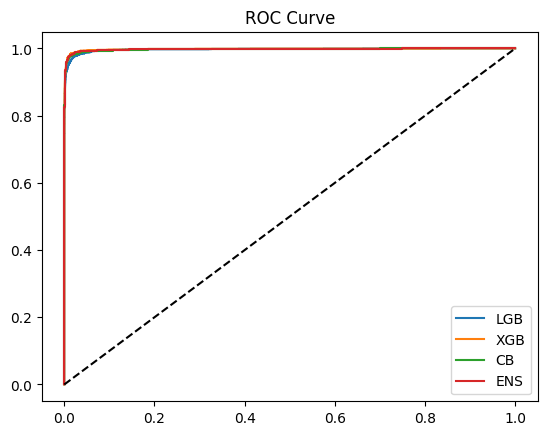

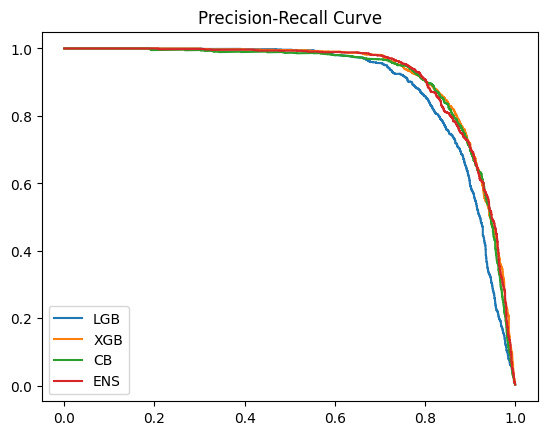

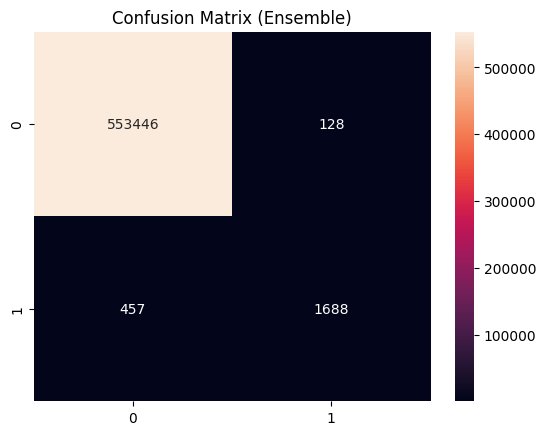

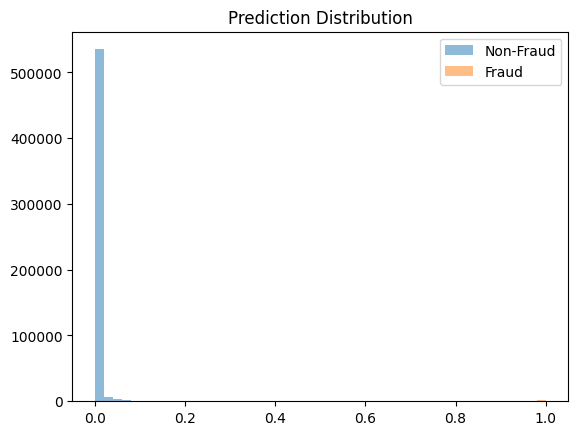

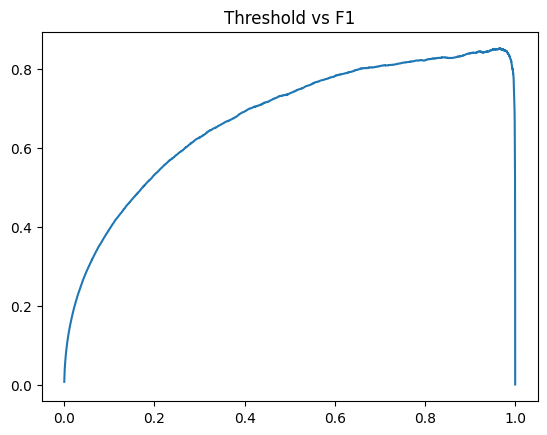

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


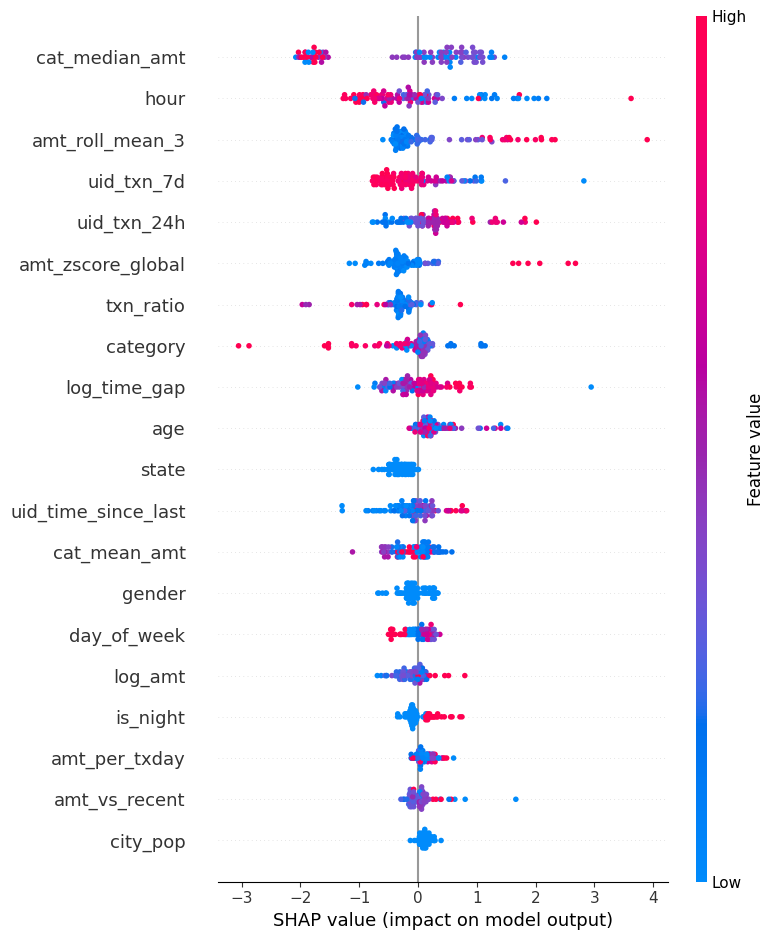

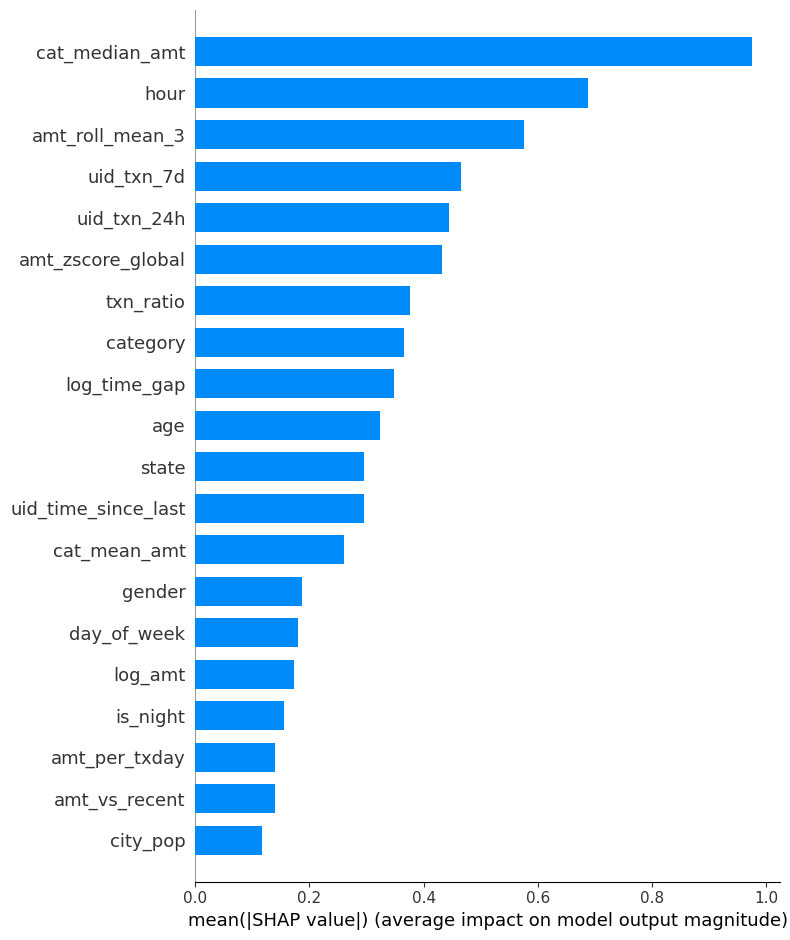

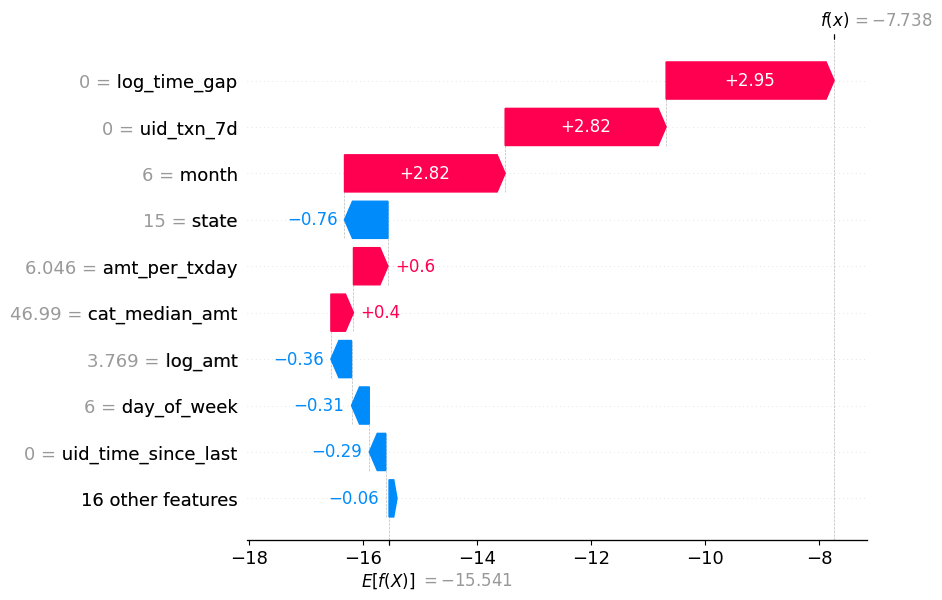

In [8]:
import pandas as pd
import numpy as np
import joblib, json
import xgboost as xgb
from catboost import CatBoostClassifier
import shap
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    precision_recall_curve, roc_curve
)

# =============================
# LOAD ARTIFACTS
# =============================
lgb_model = joblib.load("lgb_final_model.pkl")

xgb_model = xgb.XGBClassifier()
xgb_model.load_model("xgb_final_model.json")

cb_model = CatBoostClassifier()
cb_model.load_model("cb_final_model.cbm")

encoders = joblib.load("label_encoders.pkl")

with open("selected_features.json") as f:
    SELECTED = json.load(f)

stats = joblib.load("preprocessing_stats.pkl")

# =============================
# LOAD DATA
# =============================
df = pd.read_csv("fraudTest.csv")

# =============================
# CLEANING
# =============================
df = df.drop(columns=[c for c in df.columns if "Unnamed" in str(c)], errors="ignore")
df = df.drop(columns=["6006"], errors="ignore")

df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"])
df["dob"] = pd.to_datetime(df["dob"])

df["merchant_clean"] = df["merchant"].str.replace(r"^fraud_", "", regex=True).str.strip()

df["cc_num"] = df["cc_num"].astype(str)
df["zip"] = df["zip"].astype(str)
df["card_uid"] = df["cc_num"] + "_" + df["dob"].astype(str) + "_" + df["zip"]

# =============================
# BASIC FEATURES
# =============================
dt = df["trans_date_trans_time"]

df["hour"] = dt.dt.hour.astype(np.int8)
df["day_of_week"] = dt.dt.dayofweek.astype(np.int8)
df["month"] = dt.dt.month.astype(np.int8)
df["is_weekend"] = (dt.dt.dayofweek >= 5).astype(np.int8)
df["is_night"] = ((df["hour"] <= 5) | (df["hour"] >= 23)).astype(np.int8)

df["age"] = ((dt - df["dob"]).dt.days / 365.25).astype(np.float32)

df["log_amt"] = np.log1p(df["amt"]).astype(np.float32)
df["log_city_pop"] = np.log1p(df["city_pop"]).astype(np.float32)

# =============================
# TEMPORAL FEATURES
# =============================
df = df.sort_values(["card_uid", "unix_time"]).reset_index(drop=True)

group = df.groupby("card_uid")

df["uid_time_since_last"] = group["unix_time"].diff().fillna(0).astype(np.float32)

df["amt_roll_mean_3"] = (
    group["amt"].shift(1)
    .rolling(3, min_periods=1)
    .mean()
    .fillna(stats["seq_global_mean"])
).astype(np.float32)

df["amt_roll_std_3"] = (
    group["amt"].shift(1)
    .rolling(3, min_periods=1)
    .std()
    .fillna(0)
).astype(np.float32)

df["amt_vs_recent"] = (df["amt"] - df["amt_roll_mean_3"]).astype(np.float32)
df["amt_change"] = (df["amt"] / (df["amt_roll_mean_3"] + 1e-6)).astype(np.float32)

df["log_time_gap"] = np.log1p(df["uid_time_since_last"]).astype(np.float32)

def txn_counts(group):
    t = group["unix_time"].values
    n = len(t)
    txn_24h = np.zeros(n, dtype=np.int32)
    txn_7d = np.zeros(n, dtype=np.int32)

    for i in range(n):
        txn_24h[i] = np.sum((t >= t[i] - 86400) & (t < t[i]))
        txn_7d[i] = np.sum((t >= t[i] - 604800) & (t < t[i]))

    group["uid_txn_24h"] = txn_24h
    group["uid_txn_7d"] = txn_7d
    return group

df = df.groupby("card_uid", group_keys=False).apply(txn_counts)

df["txn_ratio"] = (df["uid_txn_24h"] / (df["uid_txn_7d"] + 1)).astype(np.float32)

# =============================
# GLOBAL + CATEGORY FEATURES
# =============================
df["amt_zscore_global"] = (
    (df["amt"] - stats["global_amt_mean"]) / stats["global_amt_std"]
).astype(np.float32)

cat_agg = stats["cat_agg"]
df = df.merge(cat_agg, on="category", how="left")

df["cat_mean_amt"] = df["cat_mean_amt"].fillna(stats["global_amt_mean"])
df["cat_median_amt"] = df["cat_median_amt"].fillna(stats["global_amt_mean"])

df["amt_per_txday"] = (df["amt"] / (df["day_of_week"] + 1)).astype(np.float32)

# =============================
# ENCODING
# =============================
for col, le in encoders.items():
    known = set(le.classes_)
    df[col] = df[col].astype(str).apply(lambda x: x if x in known else "<unseen>")
    df[col] = le.transform(df[col]).astype(np.int16)

# =============================
# FINAL DATA
# =============================
X = df[SELECTED].values.astype(np.float32)
y = df["is_fraud"].values

# =============================
# PREDICTIONS
# =============================
lgb_prob = lgb_model.predict_proba(X)[:,1]
xgb_prob = xgb_model.predict_proba(X)[:,1]
cb_prob  = cb_model.predict_proba(X)[:,1]
ens_prob = (lgb_prob + xgb_prob + cb_prob) / 3

# =============================
# METRICS
# =============================
def best_threshold(y_true, y_prob):
    p, r, t = precision_recall_curve(y_true, y_prob)
    f1 = 2 * p * r / (p + r + 1e-9)
    return t[np.argmax(f1[:-1])]

def evaluate(name, y_true, y_prob):
    thr = best_threshold(y_true, y_prob)
    yp = (y_prob >= thr).astype(int)

    print(f"\n{name}")
    print("PR-AUC   :", average_precision_score(y_true, y_prob))
    print("ROC-AUC  :", roc_auc_score(y_true, y_prob))
    print("Precision:", precision_score(y_true, yp))
    print("Recall   :", recall_score(y_true, yp))
    print("F1 Score :", f1_score(y_true, yp))
    print("Threshold:", thr)

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, yp))

    print("\nClassification Report:")
    print(classification_report(y_true, yp))

evaluate("LightGBM", y, lgb_prob)
evaluate("XGBoost", y, xgb_prob)
evaluate("CatBoost", y, cb_prob)
evaluate("Ensemble", y, ens_prob)

# =============================
# VISUALIZATIONS
# =============================

# ROC
plt.figure()
for name, prob in [("LGB", lgb_prob), ("XGB", xgb_prob), ("CB", cb_prob), ("ENS", ens_prob)]:
    fpr, tpr, _ = roc_curve(y, prob)
    plt.plot(fpr, tpr, label=name)
plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve")
plt.legend()
plt.show()

# PR
plt.figure()
for name, prob in [("LGB", lgb_prob), ("XGB", xgb_prob), ("CB", cb_prob), ("ENS", ens_prob)]:
    p, r, _ = precision_recall_curve(y, prob)
    plt.plot(r, p, label=name)
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

# Confusion Matrix (Ensemble)
thr = best_threshold(y, ens_prob)
yp = (ens_prob >= thr).astype(int)
sns.heatmap(confusion_matrix(y, yp), annot=True, fmt="d")
plt.title("Confusion Matrix (Ensemble)")
plt.show()

# Distribution
plt.hist(ens_prob[y==0], bins=50, alpha=0.5, label="Non-Fraud")
plt.hist(ens_prob[y==1], bins=50, alpha=0.5, label="Fraud")
plt.legend()
plt.title("Prediction Distribution")
plt.show()

# Threshold vs F1
p, r, t = precision_recall_curve(y, ens_prob)
f1 = 2*p*r/(p+r+1e-9)
plt.plot(t, f1[:-1])
plt.title("Threshold vs F1")
plt.show()

# =============================
# SHAP
# =============================
explainer = shap.TreeExplainer(lgb_model)

sample = X[:100]
shap_values = explainer.shap_values(sample)
if isinstance(shap_values, list):
    shap_values = shap_values[1]

# SHAP Summary
shap.summary_plot(shap_values, sample, feature_names=SELECTED)

# SHAP Bar
shap.summary_plot(shap_values, sample, feature_names=SELECTED, plot_type="bar")

# SHAP Waterfall (single)
base = explainer.expected_value
if isinstance(base, list):
    base = base[1]

shap.plots.waterfall(shap.Explanation(
    values=shap_values[0],
    base_values=base,
    data=sample[0],
    feature_names=SELECTED
))